Mounted at /content/drive


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 19)             │           247 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694 (2.71 KB)

 Trainable params: 694 (2.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8757
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8148
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7467
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7074
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6820
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6579
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6252
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5859
Epoch 9/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5414
Epoch 10/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5022
Epoch 11/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4758
Epoch 12/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4555
Epoch 13/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4378
Epoch 14/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4216
Epoch 15/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4080
Epoc

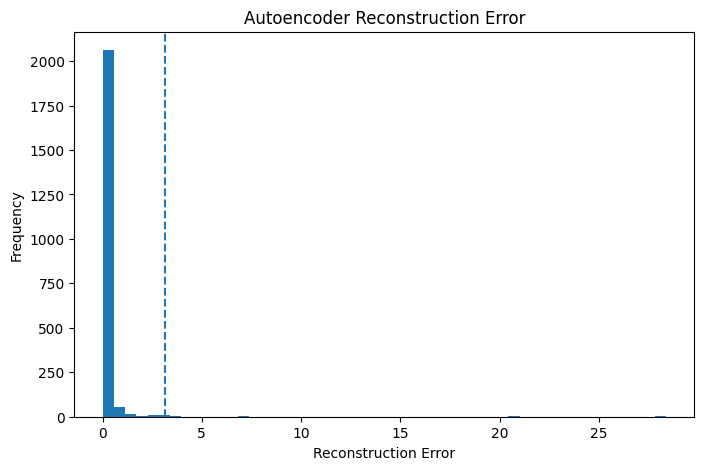

In [1]:
# =====================================================
# 04 - Autoencoder
# Mobile API Misuse Detector
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
# =====================================================
# 1. Charger dataset
# =====================================================

project_path = "/content/drive/MyDrive/Mobile_API_Misuse_Detector/"

features_df = pd.read_csv(
    project_path + "data/processed/features_dataset.csv"
)

# =====================================================
# 2. Préparer X
# =====================================================

ip_addresses = features_df["ip"]

X = features_df.drop(columns=["ip"])

# =====================================================
# 3. Normalisation
# =====================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    project_path + "models/autoencoder_scaler.pkl"
)

# =====================================================
# 4. Construire Autoencoder
# =====================================================

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(12, activation="relu")(input_layer)
encoded = Dense(6, activation="relu")(encoded)
encoded = Dense(3, activation="relu")(encoded)

decoded = Dense(6, activation="relu")(encoded)
decoded = Dense(12, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()
# =====================================================
# 5. Entraîner Autoencoder
# =====================================================

early_stop = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

# =====================================================
# 6. Calculer reconstruction error
# =====================================================

X_pred = autoencoder.predict(X_scaled)

reconstruction_error = np.mean(
    np.square(X_scaled - X_pred),
    axis=1
)

features_df["ae_reconstruction_error"] = reconstruction_error

# =====================================================
# 7. Définir seuil anomalie
# =====================================================

threshold = reconstruction_error.mean() + 2 * reconstruction_error.std()

print("Threshold:", threshold)
# =====================================================
# 8. Prédire anomalies
# =====================================================

features_df["ae_prediction"] = np.where(
    features_df["ae_reconstruction_error"] > threshold,
    -1,
    1
)

features_df["ae_prediction"].value_counts()

# =====================================================
# 9. Afficher anomalies Autoencoder
# =====================================================

ae_anomalies = features_df[
    features_df["ae_prediction"] == -1
].sort_values(
    by="ae_reconstruction_error",
    ascending=False
)

ae_anomalies.head(20)


# =====================================================
# 10. Visualiser erreurs
# =====================================================

plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error, bins=50)
plt.axvline(threshold, linestyle="--")
plt.title("Autoencoder Reconstruction Error")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()



In [2]:
ae_anomalies = features_df[
    features_df["ae_prediction"] == -1
].sort_values(
    by="ae_reconstruction_error",
    ascending=False
)

ae_anomalies.head(20)

,ip,request_count,max_req_count_5min,avg_req_count_5min,requests_per_second,avg_time_between_requests,unique_endpoints,unique_ids_accessed,status_404_count,max_error_rate_5min,...,mobile_ratio,post_frequency,max_repeated_endpoint_hits,login_attempt_count,failed_login_count,failed_login_rate,max_login_req_per_min,avg_time_between_login_attempts,ae_reconstruction_error,ae_prediction
1953,83.122.3.201,2,2,2.000000,0.117647,17.000000,2,11,0,0.000000,...,1.000000,0.500000,1,0,0,0.0,0.0,0.000000,28.398280,-1
334,2.179.141.98,6,6,6.000000,0.461538,2.600000,5,6,0,0.000000,...,0.000000,0.500000,2,0,0,0.0,0.0,0.000000,27.907220,-1
2127,91.99.72.15,1725,121,45.394737,0.156463,6.395012,1624,3730,6,0.069767,...,0.000000,0.000000,9,0,0,0.0,0.0,0.000000,27.729133,-1
411,207.46.13.9,1276,81,49.076923,0.174103,5.748235,1261,812,14,0.068966,...,0.014890,0.000000,2,6,0,0.0,1.0,1387.600000,23.772707,-1
1835,66.249.66.91,4160,202,109.473684,0.377393,2.650397,3789,1273,2,0.056604,...,0.087019,0.000000,349,0,0,0.0,0.0,0.000000,20.835975,-1
146,172.20.2.174,373,70,10.081081,0.033949,29.534946,59,29,2,0.028571,...,0.000000,0.000000,307,0,0,0.0,0.0,0.000000,20.609888,-1
1412,5.78.198.52,26,26,26.000000,0.361111,2.880000,14,31,0,0.000000,...,1.000000,0.423077,11,0,0,0.0,0.0,0.000000,19.018026,-1
492,34.247.132.53,186,7,5.027027,0.016940,59.351351,1,0,0,0.285714,...,0.000000,0.000000,186,0,0,0.0,0.0,0.000000,9.369043,-1
1828,66.249.66.194,6557,243,172.552632,0.594793,1.681513,5561,2409,459,0.246988,...,0.589904,0.000000,33,0,0,0.0,0.0,0.000000,8.527850,-1
287,194.94.127.7,459,239,114.750000,0.110257,9.089520,269,196,0,0.000000,...,0.000000,0.000000,8,1,0,0.0,1.0,0.000000,8.070170,-1


In [3]:
# =====================================================
# 11. Sauvegarder modèle + résultats
# =====================================================

autoencoder.save(
    project_path + "models/autoencoder.h5"
)

features_df.to_csv(
    project_path + "data/processed/autoencoder_results.csv",
    index=False
)

print("Autoencoder sauvegardé avec succès.")

Autoencoder sauvegardé avec succès.
